# BINN package vs BINN-as-GNN baselines on TCGA (Tumor vs Normal)

This notebook is structured to support *scientific comparison*:

- **One dataset**, one split (or repeated splits)
- **One knowledge graph**, represented once
- Models differ only by explicit toggles (edge weight sharing, attention-like gating, padding vs native DAG)
- A small **pytest suite** is run to guarantee the core equivalence claims did not break



In [1]:
# ==== 0) (Colab) clone + install (recommended if you want to run pytest) ====
# If you opened this notebook directly from GitHub in Colab, you usually want a local clone:
#
# !git clone https://github.com/<YOUR-ORG>/<YOUR-REPO>.git
# %cd <YOUR-REPO>
# !pip -q install -e .
#
# If you only want to *run models* (not tests), you can also do:
# !pip -q install git+https://github.com/<YOUR-ORG>/<YOUR-REPO>.git

In [2]:
from google.colab import drive
drive.mount('/content/drive')

import sys
from pathlib import Path
import os

PROJECT_ROOT = Path("/content/drive/MyDrive/binn_gnn_repo_ready")

sys.path.append(str(PROJECT_ROOT / "src"))
os.environ["BINN_GNN_BASE"] = str(PROJECT_ROOT)

print("Project root:", PROJECT_ROOT)

Mounted at /content/drive
Project root: /content/drive/MyDrive/binn_gnn_repo_ready


In [3]:
!pip install torch torchvision torchaudio
!pip install torch-geometric
!pip install pandas numpy scikit-learn tqdm shap

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 63.7/63.7 kB 2.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.3/1.3 MB 22.2 MB/s eta 0:00:00


In [4]:
import os
os.listdir("/content/drive/MyDrive/binn_gnn_repo_ready/outputs")

['graph',
 'expr_reactome_tcga_tumor_normal.parquet',
 'graph_layered_binn',
 'cache_tensors',
 'runs_compare',
 'reactome_downloads',
 'y_tcga_tumor_normal.csv']

In [5]:
# ==== 1) Run unit tests (recommended) ====
# In Colab this requires the repo to be cloned (so the `tests/` folder exists).
import os, pathlib, sys, subprocess, textwrap

if pathlib.Path("tests").exists():
    print("Running pytest...")
    !pytest -q
else:
    print("No local `tests/` folder found.")
    print("If you're in Colab, clone the repo and install editable mode, then rerun this cell.")

No local `tests/` folder found.
If you're in Colab, clone the repo and install editable mode, then rerun this cell.


In [6]:
# ==== 2) Setup: paths + run config ====
from pathlib import Path
import os, json, time
import numpy as np
import pandas as pd
import torch
from sklearn.model_selection import train_test_split
from sklearn.metrics import roc_auc_score

BASE_DIR = Path(os.environ.get("BINN_GNN_BASE", ".")).resolve()
OUT_DIR  = BASE_DIR / "outputs"
RAW_GRAPH_DIR = OUT_DIR / "graph"
LAYERED_GRAPH_DIR = OUT_DIR / "graph_layered_binn"

# Cached dataset
EXPR_PARQUET = OUT_DIR / "expr_reactome_tcga_tumor_normal.parquet"
Y_CSV        = OUT_DIR / "y_tcga_tumor_normal.csv"

# Run config (small defaults for quick iterations)
SEED = 42
EPOCHS = 5          # increase for better comparisons
BATCH_SIZE = 32
LR = 1e-3
WEIGHT_DECAY = 1e-5
DROPOUT = 0.2
D_VECTOR = 16
VAL_FRAC = 0.2

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("device:", device)

def set_seed(seed=42):
    import random
    random.seed(seed); np.random.seed(seed)
    torch.manual_seed(seed); torch.cuda.manual_seed_all(seed)

set_seed(SEED)

required = [
    EXPR_PARQUET, Y_CSV,
    RAW_GRAPH_DIR / "node_table.csv", RAW_GRAPH_DIR / "edge_index.pt", RAW_GRAPH_DIR / "edge_table.csv",
    LAYERED_GRAPH_DIR / "node_table_layered.csv", LAYERED_GRAPH_DIR / "edge_table_layered.csv", LAYERED_GRAPH_DIR / "edge_index_layered.pt",
]
missing = [str(p) for p in required if not p.exists()]
if missing:
    raise FileNotFoundError("Missing required files:\n" + "\n".join(missing))

device: cpu


In [7]:
# ==== 3) Load dataset and create ONE fixed split (shared across baselines) ====
expr = pd.read_parquet(EXPR_PARQUET)   # genes x samples
y_df = pd.read_csv(Y_CSV, index_col=0)

samples = y_df.index.astype(str).tolist()
y_np = y_df.iloc[:,0].to_numpy(dtype=np.int64)

# Align expression columns to y order
expr = expr.loc[:, samples]

X_gene = torch.tensor(expr.to_numpy(dtype=np.float32).T)  # samples x genes
y = torch.tensor(y_np, dtype=torch.long)

print("X_gene:", tuple(X_gene.shape), "y:", tuple(y.shape), "tumor_frac:", float(y.float().mean()))

idx = np.arange(len(samples))
train_idx, val_idx = train_test_split(idx, test_size=VAL_FRAC, random_state=SEED, stratify=y_np)

train_idx = torch.tensor(train_idx, dtype=torch.long)
val_idx   = torch.tensor(val_idx, dtype=torch.long)

train_samples = [samples[i] for i in train_idx.tolist()]
val_samples   = [samples[i] for i in val_idx.tolist()]

print("train:", len(train_samples), "val:", len(val_samples))

X_gene: (9912, 11403) y: (9912,) tumor_frac: 0.926654577255249
train: 7929 val: 1983


In [8]:
# ==== 4) Utilities: timing + memory ====
import os, gc, time
from contextlib import contextmanager
from sklearn.metrics import roc_auc_score

try:
    import psutil
except ImportError:
    # Colab sometimes lacks psutil
    !pip -q install psutil
    import psutil

def rss_mb() -> float:
    return psutil.Process(os.getpid()).memory_info().rss / (1024**2)

@contextmanager
def timer():
    t0 = time.time()
    yield lambda: time.time() - t0

def roc_auc(y_true, prob_pos):
    return roc_auc_score(y_true, prob_pos)

In [9]:
# ==== 5) Build model inputs: layered schedule + native DAG schedule ====
import numpy as np
import pandas as pd
import torch

from binn_gnn.graph.schedule import build_layered_schedule, build_depth_schedule

# ----- Layered schedule (padded, feedforward BINN constraint) -----
node_layered = pd.read_csv(LAYERED_GRAPH_DIR / "node_table_layered.csv")
edge_layered = pd.read_csv(LAYERED_GRAPH_DIR / "edge_table_layered.csv")
edge_index_layered = torch.load(LAYERED_GRAPH_DIR / "edge_index_layered.pt").long()

root_path = LAYERED_GRAPH_DIR / "root_pathway_idx.pt"
if root_path.exists():
    root_ids_layered = torch.load(root_path).long().tolist()
else:
    # fallback: max-layer copy of each root pathway by orig_id
    root_ids_layered = (
        node_layered.query("node_type=='pathway'")
        .groupby("orig_id")["layered_id"]
        .max()
        .astype(int)
        .tolist()
    )

layered_schedule = build_layered_schedule(
    edge_index=edge_index_layered,
    node_layer=node_layered["layer"].to_numpy(dtype=np.int64),
    edge_type=edge_layered["edge_type"].astype(str).tolist(),
    gene_ids=node_layered.query("node_type=='gene' and layer==0")["layered_id"].astype(int).tolist(),
    root_ids=root_ids_layered,
)

# expression gene order -> layered gene node ids
gene_rows = node_layered.query("node_type=='gene' and layer==0")[["orig_name","layered_id"]]
gene_to_layered = dict(zip(gene_rows["orig_name"].astype(str), gene_rows["layered_id"].astype(int)))
gene_map_layered = torch.tensor([gene_to_layered[g] for g in expr.index.astype(str)], dtype=torch.long)

print("Layered | N:", layered_schedule.N, "E:", layered_schedule.E, "L:", layered_schedule.L, "roots:", layered_schedule.root_ids.numel())

# ----- Raw DAG schedule (no padding) -----
node_raw = pd.read_csv(RAW_GRAPH_DIR / "node_table.csv")
edge_table_raw = pd.read_csv(RAW_GRAPH_DIR / "edge_table.csv")
edge_index_raw = torch.load(RAW_GRAPH_DIR / "edge_index.pt").long()

num_genes_raw = int((node_raw["node_type"]=="gene").sum())
raw_gene_names = node_raw.query("node_type=='gene'")["node_name"].astype(str).tolist()
raw_gene_to_id = {g:i for i,g in enumerate(raw_gene_names)}
gene_map_raw = torch.tensor([raw_gene_to_id[g] for g in expr.index.astype(str)], dtype=torch.long)

pw = edge_table_raw.query("edge_type=='pathway_to_parent'")[["src","dst"]].astype(int)
root_ids_raw = sorted(set(pw["dst"].tolist()) - set(pw["src"].tolist()))

depth_schedule = build_depth_schedule(
    edge_index=edge_index_raw,
    gene_ids=list(range(num_genes_raw)),
    root_ids=root_ids_raw,
)
print("Raw DAG | N:", depth_schedule.N, "E:", depth_schedule.E, "D:", depth_schedule.D, "roots:", len(root_ids_raw))

Layered | N: 16283 E: 44955 L: 12 roots: 29
Raw DAG | N: 14201 E: 140581 D: 12 roots: 29


In [10]:
# ==== 6) GNN-style baselines (imported from the package) ====
from binn_gnn.models.layered import BINNExactD1, GCNSharedD1, GATGateD1, VectorSharedD, DenseMLPBaseline
from binn_gnn.models.dag import DAGBINNExactD1

def make_models():
    return {
        # key point: include the *exact* layered BINN-as-MPNN (unique edge weights, scalar nodes)
        "layered_binn_exact_d1": BINNExactD1(schedule=layered_schedule, gene_map=gene_map_layered, dropout=DROPOUT, learn_padding=False),

        # relaxations
        "layered_gcn_shared_d1": GCNSharedD1(schedule=layered_schedule, gene_map=gene_map_layered, dropout=DROPOUT),
        "layered_gat_gate_d1":   GATGateD1(schedule=layered_schedule, gene_map=gene_map_layered, dropout=DROPOUT),
        "layered_vector_shared_d16": VectorSharedD(schedule=layered_schedule, gene_map=gene_map_layered, d=D_VECTOR, dropout=DROPOUT),

        # remove padding (native DAG propagation)
        "dag_binn_exact_d1": DAGBINNExactD1(schedule=depth_schedule, gene_map=gene_map_raw, dropout=DROPOUT),

        # dense baseline
        "dense_mlp": DenseMLPBaseline(in_dim=X_gene.shape[1], dropout=DROPOUT),
    }

In [11]:
# ==== 7) Train/eval loop (shared) ====
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import DataLoader, TensorDataset
from tqdm.auto import tqdm

X_train = X_gene[train_idx].to(device)
y_train = y[train_idx].to(device)

X_val = X_gene[val_idx].to(device)
y_val = y[val_idx].to(device)

train_loader = DataLoader(TensorDataset(X_train, y_train), batch_size=BATCH_SIZE, shuffle=True)
val_loader   = DataLoader(TensorDataset(X_val, y_val), batch_size=256, shuffle=False)

def train_model(model, name):
    print("\n==============================")
    print("Training model:", name)
    print("==============================")

    model = model.to(device)
    opt = torch.optim.Adam(model.parameters(), lr=LR, weight_decay=WEIGHT_DECAY)

    # class weights (simple)
    counts = torch.bincount(y_train)
    w = (1.0 / counts.float()).to(device)
    crit = nn.CrossEntropyLoss(weight=w)

    epoch_times=[]
    mem0 = rss_mb()

    best_auc = -1.0
    best_state = None

    for ep in range(1, EPOCHS + 1):
        model.train()
        running_loss = 0.0
        n_seen = 0

        with timer() as dt:
            for xb, yb in tqdm(train_loader, desc=f"{name} train {ep}/{EPOCHS}"):
                opt.zero_grad(set_to_none=True)
                logits = model(xb)
                loss = crit(logits, yb)
                loss.backward()
                opt.step()
                running_loss += float(loss.item()) * xb.size(0)
                n_seen += xb.size(0)

        epoch_times.append(dt())
        train_loss = running_loss / max(n_seen,1)

        # ---- validation ----
        model.eval()
        probs=[]
        ys=[]
        val_loss = 0.0
        val_seen = 0

        with torch.no_grad():
            for xb, yb in val_loader:
                logits = model(xb)
                loss = crit(logits, yb)
                val_loss += float(loss.item()) * xb.size(0)
                val_seen += xb.size(0)

                p = torch.softmax(logits, dim=1)[:,1]
                probs.append(p.cpu().numpy())
                ys.append(yb.cpu().numpy())

        val_loss = val_loss / max(val_seen,1)
        probs = np.concatenate(probs)
        ys = np.concatenate(ys)
        auc = roc_auc(ys, probs)

        print(f"{name} | epoch {ep}/{EPOCHS} | train_loss {train_loss:.4f} | val_loss {val_loss:.4f} | val_auc {auc:.4f}")

        if auc > best_auc:
            best_auc = auc
            best_state = {k: v.detach().cpu().clone() for k,v in model.state_dict().items()}

    if best_state is not None:
        model.load_state_dict(best_state)

    mem1 = rss_mb()

    # ---- inference speed ----
    def infer_fn(xb):
        logits = model(xb)
        return torch.softmax(logits, dim=1)[:,1]

    # warmup
    with torch.no_grad():
        for xb,_ in val_loader:
            _ = infer_fn(xb)
            break

    with timer() as dt_inf:
        with torch.no_grad():
            for xb,_ in val_loader:
                _ = infer_fn(xb)

    sec_per_1k = dt_inf() / (len(X_val)/1000.0)

    result = {
        "model": name,
        "val_auc": float(best_auc),
        "sec_per_epoch": float(np.mean(epoch_times)),
        "rss_mb_delta": float(mem1-mem0),
        "sec_per_1k_infer": float(sec_per_1k),
    }
    print("Summary:", result)
    return result

In [12]:
# ==== 8) Run the GNN baselines ====
results = []
models = make_models()

for name, model in models.items():
    results.append(train_model(model, name))

df_results = pd.DataFrame(results).sort_values("val_auc", ascending=False)
df_results


Training model: layered_binn_exact_d1


layered_binn_exact_d1 train 1/5:   0%|          | 0/248 [00:00<?, ?it/s]

layered_binn_exact_d1 | epoch 1/5 | train_loss 0.6863 | val_loss 0.6640 | val_auc 0.9752


layered_binn_exact_d1 train 2/5:   0%|          | 0/248 [00:00<?, ?it/s]

layered_binn_exact_d1 | epoch 2/5 | train_loss 0.6398 | val_loss 0.5378 | val_auc 0.9768


...

dense_mlp train 4/5:   0%|          | 0/248 [00:00<?, ?it/s]

dense_mlp | epoch 4/5 | train_loss 0.1950 | val_loss 0.1060 | val_auc 0.9917


dense_mlp train 5/5:   0%|          | 0/248 [00:00<?, ?it/s]

dense_mlp | epoch 5/5 | train_loss 0.1825 | val_loss 0.1153 | val_auc 0.9931
Summary: {'model': 'dense_mlp', 'val_auc': 0.9931297137068027, 'sec_per_epoch': 9.867079734802246, 'rss_mb_delta': 1.05078125, 'sec_per_1k_infer': 0.12512009851991437}


,model,val_auc,sec_per_epoch,rss_mb_delta,sec_per_1k_infer
5,dense_mlp,0.993130,9.867080,1.050781,0.125120
4,dag_binn_exact_d1,0.989708,22.670414,0.171875,0.811505
0,layered_binn_exact_d1,0.985423,14.044049,56.214844,0.521771
3,layered_vector_shared_d16,0.507452,232.612238,274.316406,8.832406
1,layered_gcn_shared_d1,0.500000,12.546090,78.093750,0.715233
2,layered_gat_gate_d1,0.500000,21.388649,158.289062,1.339696


## 9) Official BINN package baseline (optional)

If you want to compare against the external `binn` package, keep it as a *separate* baseline block.

Important for fairness:

- Use the same `VAL_FRAC` and `SEED`.
- Set `n_layers` to match the layered graph depth used above (here: `layered_schedule.L`).
- Be explicit about any other defaults (activation, normalization, etc.) that differ.


In [13]:
# OPTIONAL: Official BINN package baseline
# NOTE: This cell requires internet access (Colab) to `pip install binn`.

# !pip -q install binn
# from binn import BINN, BINNDataLoader, BINNTrainer

# # Reactome files should already exist from 01_graph_preparation; if not, download them there.
# REACTOME_DIR = OUT_DIR / "reactome_downloads"
# ENSEMBL2R = REACTOME_DIR / "Ensembl2Reactome.txt"
# RELFILE  = REACTOME_DIR / "ReactomePathwaysRelation.txt"

# # Build the BINN data_matrix (genes x samples)
# # Important: binn expects a "Gene" column and genes as rows.
# gene_names = expr.index.to_series().astype(str).str.replace(r"\.\d+$", "", regex=True)
# data_matrix = pd.DataFrame(X_gene.cpu().numpy().T, index=gene_names, columns=samples)
# data_matrix.insert(0, "Gene", data_matrix.index)

# design_matrix = pd.DataFrame({
#     "sample": samples,
#     "group": np.where(y_np==1, "tumor", "normal")
# })

# # mapping + hierarchy
# ens2rea = pd.read_csv(ENSEMBL2R, sep="\t", header=None)
# ens2rea.columns = ["input","translation","url","name","evidence","species"]
# ens2rea = ens2rea[
#     (ens2rea["species"]=="Homo sapiens") &
#     ens2rea["input"].astype(str).str.startswith("ENSG") &
#     ens2rea["translation"].astype(str).str.startswith("R-HSA-")
# ].copy()
# ens2rea["input"] = ens2rea["input"].astype(str).str.replace(r"\.\d+$","", regex=True)
# mapping_df = ens2rea[["input","translation"]].drop_duplicates()

# rel = pd.read_csv(RELFILE, sep="\t", header=None, names=["child","parent"])
# rel = rel[
#     rel["child"].astype(str).str.startswith("R-HSA-") &
#     rel["parent"].astype(str).str.startswith("R-HSA-")
# ]
# pathways_df = rel.rename(columns={"child":"source","parent":"target"}).drop_duplicates()

# # Critical: align n_layers to the graph depth used by our layered schedule.
# n_layers = int(layered_schedule.L)

# binn_model = BINN(
#     data_matrix=data_matrix,
#     mapping=mapping_df,
#     pathways=pathways_df,
#     entity_col="Gene",
#     input_col="input",
#     translation_col="translation",
#     source_col="source",
#     target_col="target",
#     n_layers=n_layers,
#     dropout=DROPOUT,
#     device=("cuda" if torch.cuda.is_available() else "cpu"),
# )

# binn_dl = BINNDataLoader(binn_model)
# dls = binn_dl.create_dataloaders(
#     data_matrix=data_matrix,
#     design_matrix=design_matrix,
#     feature_column="Gene",
#     group_column="group",
#     sample_column="sample",
#     batch_size=BATCH_SIZE,
#     validation_split=VAL_FRAC,
#     random_state=SEED,
# )

# trainer = BINNTrainer(binn_model)
# trainer.fit(dataloaders=dls, num_epochs=EPOCHS)

# # Evaluate AUC on dls["val"]
# binn_model.eval()
# probs=[]
# ys=[]
# with torch.no_grad():
#     for xb, yb in dls["val"]:
#         xb = xb.to(binn_model.device)
#         logits = binn_model(xb)
#         p = torch.softmax(logits, dim=1)[:,1].cpu().numpy()
#         probs.append(p); ys.append(yb.numpy())
# auc_binn = roc_auc_score(np.concatenate(ys), np.concatenate(probs))
# print("official_binn val_auc:", auc_binn)

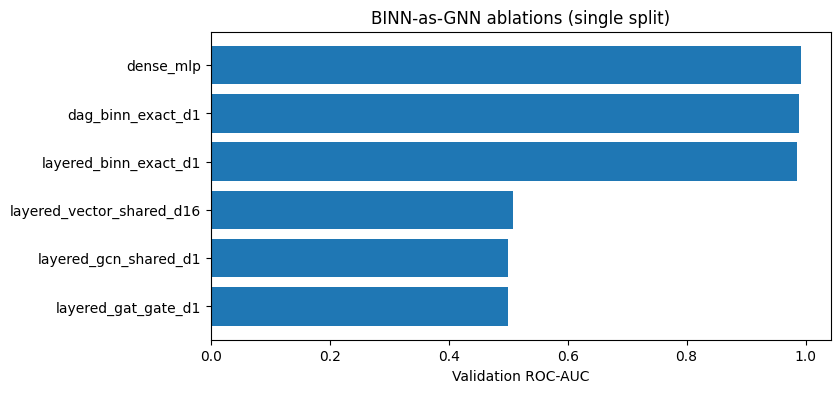

In [14]:
# ==== 10) Quick visualization ====
import matplotlib.pyplot as plt

df_plot = df_results.sort_values("val_auc", ascending=True)

plt.figure(figsize=(8, 4))
plt.barh(df_plot["model"], df_plot["val_auc"])
plt.xlabel("Validation ROC-AUC")
plt.title("BINN-as-GNN ablations (single split)")
plt.show()